In [1]:
import pandas as pd

personas = pd.read_csv("../outputs/customer_personas.csv")
rfm_raw = pd.read_csv("../outputs/rfm_raw.csv")

data = personas.merge(
    rfm_raw,
    on="customer_unique_id",
    how="left"
)

data.head()

,customer_unique_id,recency_x,frequency_x,monetary_x,nlp_1,nlp_2,cluster,persona,recency_y,frequency_y,monetary_y
0,0000366f3b9a7992bf8c76cfdf3221e2,0.157967,0.0,0.009603,7.955969,0.534592,1,Silent Loyal Customers,116,1,129.90
1,0000f6ccb0745a6a4b88665a16c9f078,0.446429,0.0,0.001871,13.129206,11.164166,0,High-Value Enthusiasts,326,1,25.99
2,00053a61a98854899e70ed204dd4bafe,0.255495,0.0,0.028361,4.529376,4.633020,0,High-Value Enthusiasts,187,1,382.00
3,0005ef4cd20d2893f0d9fbd94d3c0d97,0.239011,0.0,0.007742,5.494314,1.528532,1,Silent Loyal Customers,175,1,104.90
4,0006fdc98a402fceb4eb0ee528f6a8d4,0.564560,0.0,0.000971,5.508366,-0.480954,1,Silent Loyal Customers,412,1,13.90


In [4]:
# Use raw (real-world) RFM values for agent decisions
data["recency_days"] = data["recency_y"]
data["frequency_raw"] = data["frequency_y"]
data["monetary_raw"] = data["monetary_y"]

In [5]:
# Agent perception (context signals)
data["long_inactive"] = data["recency_days"] > 200
data["very_long_inactive"] = data["recency_days"] > 350
data["negative_review"] = data["nlp_2"] < -5

In [6]:
def agent_decision(row):
    # High-value customers with complaints
    if (
        row["persona"] == "High-Value Enthusiasts"
        and row["negative_review"]
    ):
        return "Gift + Apology Email"

    # Loyal customers showing dissatisfaction
    if (
        row["persona"] == "Silent Loyal Customers"
        and row["negative_review"]
    ):
        return "Loyalty Points + Feedback Request"

    # Emerging customers at churn risk
    if (
        row["persona"] == "Emerging Loyalists"
        and row["long_inactive"]
    ):
        return "Personalized Discount Offer"

    # Fading or churn-risk customers
    if (
        row["persona"] in ["Fading Customers", "Dissatisfied / Churn-Risk Customers"]
        and row["very_long_inactive"]
    ):
        return "Win-Back Campaign"

    # Otherwise
    return "No Action"

In [7]:
data["agent_action"] = data.apply(agent_decision, axis=1)

data["agent_action"].value_counts()

agent_action
No Action                            33067
Personalized Discount Offer           5226
Win-Back Campaign                      963
Loyalty Points + Feedback Request       66
Name: count, dtype: int64

In [8]:
agent_output = data[
    ["customer_unique_id", "persona", "agent_action"]
]

agent_output.to_csv(
    "../outputs/agent_actions.csv",
    index=False
)

print("Agent decisions saved successfully.")

Agent decisions saved successfully.


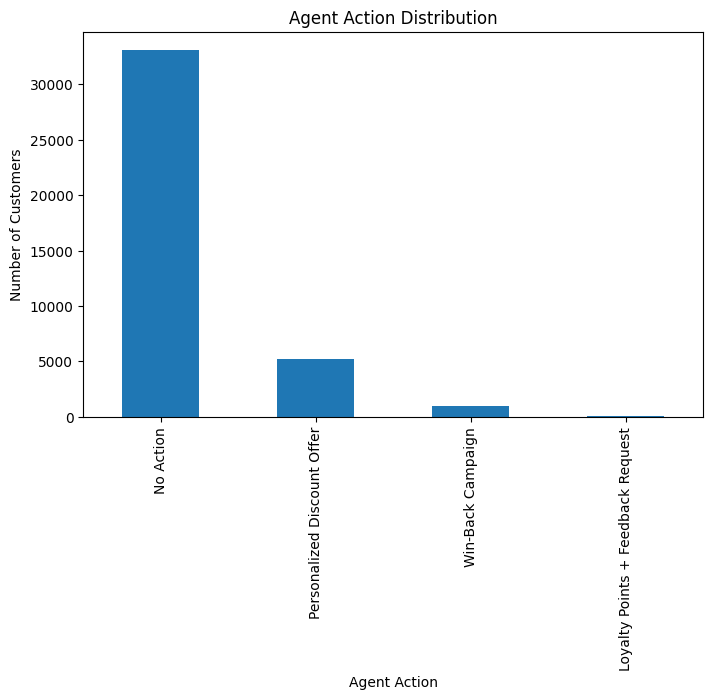

In [9]:
import matplotlib.pyplot as plt

data["agent_action"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Agent Action Distribution"
)

plt.ylabel("Number of Customers")
plt.xlabel("Agent Action")
plt.show()